In [3]:
# Data handling
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [4]:
# Load the data
df = pd.read_csv("data/OCED_simplified.csv")

In [5]:
# Identify childhood immunisation columns
childhood_cols = [
    col for col in df.columns
    if "Immunisation" in col and "65 years" not in col
]

# Build and pivot tidy dataframe
long_df = (
    df[["year", "country", *childhood_cols]]
    .melt(
        id_vars=["year", "country"],
        var_name="vaccine",
        value_name="coverage"
    )
    .assign(
        year=lambda x: pd.to_numeric(x["year"], errors="raise").astype("int64"),
        vaccine=lambda x: (
            x["vaccine"]
            .str.replace("Immunisation: ", "", regex=False)
            .str.replace("_% of children immunised", "", regex=False)
        )
    )
)

In [6]:
# Function to filter data for a specific vaccine and optional countries
def get_vaccine_data(df, vaccine, countries=None, latest_only=False):
    filtered = df.query("vaccine == @vaccine").dropna(subset=["coverage"])

    if countries:
        filtered = filtered[filtered["country"].isin(countries)]

    if latest_only:
        latest_year = filtered["year"].max()
        filtered = filtered.query("year == @latest_year")

    return filtered.copy()

In [7]:
# Example: Get latest measles immunisation data
measles_latest = get_vaccine_data(
    long_df,
    vaccine="Measles",
    latest_only=True
)

In [8]:
# Example: Get latest measles immunisation data for selected countries
selected_countries = [
    "Türkiye",
    "United Kingdom",
    "United States",
    "Brazil",
    "India"
]

measles_selected = get_vaccine_data(
    long_df,
    vaccine="Measles",
    countries=selected_countries,
    latest_only=True
)

In [9]:
# Example: Get DTP immunisation data for all years
dtp_df = get_vaccine_data(
    long_df,
    vaccine="Diphtheria, Tetanus, Pertussis"
)

In [10]:
# Calculate summary statistics for latest measles immunisation coverage
summary_stats = {
    "mean": (
        get_vaccine_data(long_df, "Measles", latest_only=True)["coverage"]
        .mean()
        .round(2)
    ),
    "median": (
        get_vaccine_data(long_df, "Measles", latest_only=True)["coverage"]
        .median()
        .round(2)
    ),
    "min": (
        get_vaccine_data(long_df, "Measles", latest_only=True)["coverage"]
        .min()
    ),
    "max": (
        get_vaccine_data(long_df, "Measles", latest_only=True)["coverage"]
        .max()
    ),
    "std": (
        get_vaccine_data(long_df, "Measles", latest_only=True)["coverage"]
        .std()
        .round(2)
    ),
    "below_95": (
        get_vaccine_data(long_df, "Measles", latest_only=True)["coverage"]
        .lt(95)
        .sum()
    )
}

In [11]:
# Display summary statistics
summary_stats["mean"]
summary_stats["below_95"]


np.int64(17)

In [ ]:
#Line chart of measles immunisation coverage over time for selected countries

# Define selected countries for the line chart
selected_countries = [
    "Türkiye",
    "United Kingdom",
    "United States",
    "Brazil",
    "India"
]

# Get measles immunisation data for selected countries
measles_selected = get_vaccine_data(
    long_df,
    vaccine="Measles",
    countries=selected_countries
)
# Create line chart
fig = px.line(
    measles_selected,
    x="year",
    y="coverage",
    color="country",
    markers=True,
    title="Measles Vaccination Coverage Over Time"
)

# WHO target line
fig.add_hline(
    y=95,
    line_dash="dash",
    line_color="darkgreen",
    annotation_text="WHO Target (95%)",
    annotation_position="top left"
)

# 90–95% shaded zone
fig.add_hrect(
    y0=90,
    y1=95,
    fillcolor="green",
    annotation_text="Below WHO target range",
    annotation_position="bottom left",
    opacity=0.15,
    line_width=0
)

# Layout formatting
fig.update_layout(
    template="plotly_white",
    xaxis_title="Year",
    yaxis_title="Coverage (%)",
    legend_title="Country",
    hovermode="x unified",
    height=600
)

# Better y-axis range
fig.update_yaxes(
    range=[
        measles_selected["coverage"].min() - 5,
        100
    ]
)

fig.show()

In [ ]:
# Horizontal bar chart of latest measles immunisation coverage by country

# Get latest measles immunisation data for all countries
measles_latest = get_vaccine_data(
    long_df,
    vaccine="Measles",
    latest_only=True
)

# Create horizontal bar chart
fig = px.bar(
    measles_latest.sort_values("coverage"),
    x="coverage",
    y="country",
    orientation="h",
    color="coverage",
    color_continuous_scale="Viridis_r", 
    title=f"Latest Measles Vaccination Coverage by Country ({measles_latest['year'].max()})"
)

# WHO target line
fig.add_vline(
    x=95,
    line_dash="dash",
    line_color="red",
    annotation_text="WHO Target (95%)",
    annotation_position="top right",
    annotation_font=dict(
    color="red",
    size=11),
    annotation_y=0.5
)

#Hover formatting
fig.update_traces(
    hovertemplate=
    "<b>%{y}</b><br>" +
    "Coverage: %{x:.1f}%<extra></extra>"
)

# Layout formatting
fig.update_layout(
    template="plotly_white",
    xaxis_title="Coverage (%)",
    yaxis_title="Country",
    coloraxis_showscale=False,
    height=700,
    width=700
)

# Dynamic axis range
fig.update_xaxes(
    range=[
        measles_latest["coverage"].min() - 5,
        measles_latest["coverage"].max() + 3
    ]
)

fig.show()

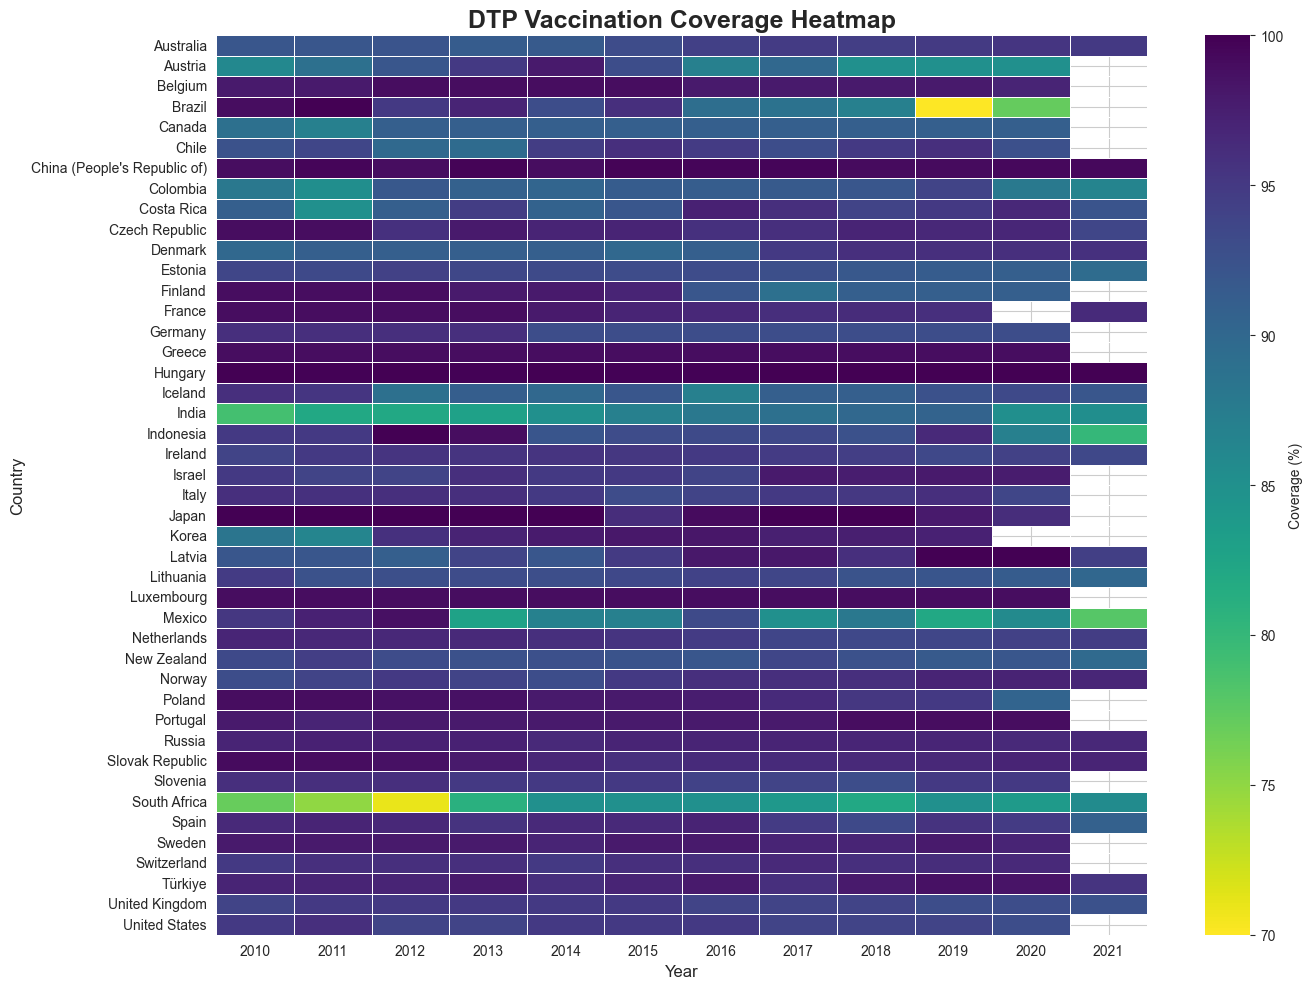

In [16]:
# DTP Vaccination Coverage Heatmap

# Prepare data for heatmap
dtp_heatmap = (
    get_vaccine_data(
        long_df,
        vaccine="Diphtheria, Tetanus, Pertussis"
    )
    .pivot_table(
        index="country",
        columns="year",
        values="coverage"
    )
)

# Create heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    dtp_heatmap,
    cmap="viridis_r",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Coverage (%)"
    }
)

plt.title(
    "DTP Vaccination Coverage Heatmap",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Country", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
long_df.columns

In [ ]:
long_df.to_csv(
    "data/clean_oecd_immunisation.csv",
    index=False
)